# Bone Age Prediction from Hand X-Rays

I am completing this project as part of my Data and Machine Learning class for medical imaging machine-learning coursework. I am building a model that uses pediatric left-hand X-ray images to estimate bone age in months.

My main goal is to understand the complete machine-learning process. This includes preparing and inspecting the dataset, checking the image and label files, training a regression model, evaluating its predictions, saving the model, and connecting it to a Streamlit application.

This is a coursework prototype and **not a medical device**. It has not been clinically validated or reviewed by a radiologist. I will not use the notebook or Streamlit application to diagnose a patient or make medical, treatment, or patient-management decisions.


## Declare My Scope

- **Body part:** pediatric hand and wrist bones.
- **Modality:** plain X-ray of the left hand.
- **Problem type:** regression (one continuous number, not classes).
- **Target:** bone age in months.
- **Dataset:** [RSNA Bone Age (Kaggle)](https://www.kaggle.com/datasets/kmader/rsna-bone-age), accessed September 13, 2026. A free Kaggle account is needed to download it.
- **Real-world question:** how accurately can a model estimate bone age from a hand X-ray?
- **Who would use it:** in real life, pediatricians and endocrinologists compare bone age with chronological age to check for growth problems. My version is for coursework review only, not for clinical use.


# A1. Problem Definition and Clinical Framing

The model takes a left-hand X-ray and predicts bone age in months. Bone age shows how mature the skeleton is, and it is often different from the person's real age. A prediction of 126 months means the skeleton looks like a typical child of about 10 years and 6 months, not that the child is exactly that age.

This is a coursework prototype. It must not replace a radiologist, paediatrician, or any qualified health professional.

I assume each input is a single left-hand X-ray that is readable and looks similar to the training images. Rotated, very dark, or very different images may give unreliable predictions.

## Step 1: Set Up the Project

In this step, I will prepare my notebook for the project.

I will install and import the libraries needed to inspect the dataset,
process the X-ray images, train the regression model, and evaluate its
predictions.

I will also set a fixed random seed so that the results can be reproduced
when I run the notebook again.

Finally, I will provide the path to the folder where I saved the RSNA Bone
Age dataset. I need to update this path to match the location of my files.

In [1]:
!pip install -q --break-system-packages pandas numpy pillow matplotlib seaborn scikit-learn tensorflow

In [1]:
import glob
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

import model_utils as mu

RANDOM_SEED = mu.RANDOM_SEED
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

DATA_ROOT = os.path.join("boneage-training-dataset", "boneage-training-dataset")
IMG_SIZE = 224

assert os.path.exists(DATA_ROOT), f"Path does not exist: {DATA_ROOT}"
print("DATA_ROOT is valid:", DATA_ROOT)
print("TensorFlow version:", tf.__version__)


I0000 00:00:1789366962.024394  139353 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789366962.105215  139353 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789366963.426254  139353 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


DATA_ROOT is valid: boneage-training-dataset/boneage-training-dataset
TensorFlow version: 2.21.0


### A2. Dataset Documentation

The RSNA Bone Age dataset has hand X-rays with a bone age label in months for each image. The images are grayscale PNGs of different sizes, so I resize them all to 224x224. Labels were written by expert pediatric radiologists, and the sex of each patient is also in the CSV.

Known limitations: the images come from a few hospitals, so other populations and scanners may look different, and there are fewer images at the very young and very old ends of the age range. The sex counts are also imbalanced, which I show below.

Next I build the list of image files, load the label CSV, and plot the age and sex distributions so I can see the imbalance with my own eyes. The numbers printed come from my actual downloaded files, not guessed.

Total images found: 5386
Total metadata entries loaded: 12611
Minimum bone age: 1 months
Maximum bone age: 228 months
Average bone age: 127.32 months


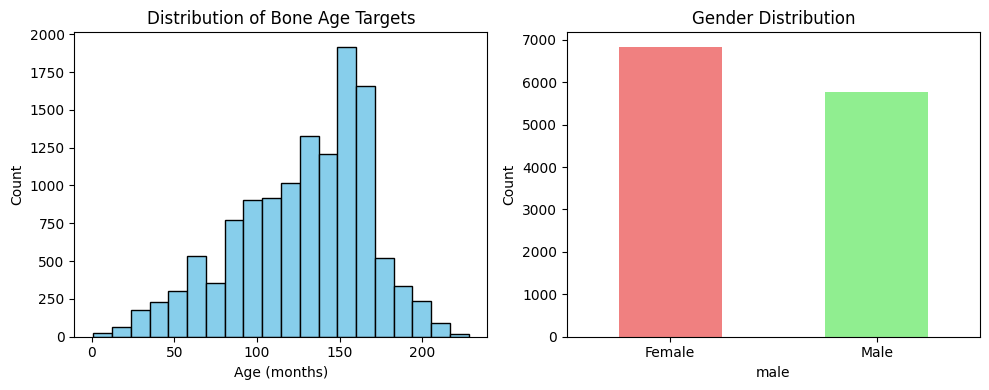

In [3]:
csv_paths = glob.glob("boneage-training-dataset.csv")
image_paths = sorted(glob.glob(os.path.join(DATA_ROOT, "*.png")))

df_master = pd.concat([pd.read_csv(p) for p in csv_paths], ignore_index=True)

print("Total images found:", len(image_paths))
print("Total metadata entries loaded:", len(df_master))
print("Minimum bone age:", df_master["boneage"].min(), "months")
print("Maximum bone age:", df_master["boneage"].max(), "months")
print("Average bone age:", round(df_master["boneage"].mean(), 2), "months")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df_master["boneage"], bins=20, color="skyblue", edgecolor="black")
plt.title("Distribution of Bone Age Targets")
plt.xlabel("Age (months)")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
if "male" in df_master.columns:
    df_master["male"].value_counts().plot(kind="bar", color=["lightcoral", "lightgreen"])
    plt.xticks([0, 1], ["Female", "Male"], rotation=0)
    plt.title("Gender Distribution")
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

### A3. Data Preparation & Splitting

Every image goes through the same steps: resize to 224x224, copy the single grayscale channel three times, and cast to float32. Pixel values stay between 0 and 255 because MobileNetV2 preprocessing is built into the model itself. I chose this so the notebook and the Streamlit app apply exactly the same steps with no scaling mistakes.

I split the training CSV into 80% training and 20% validation. The separate **boneage-test-dataset.csv** is my test set. The assertion below checks that no filename appears in more than one set. Each image is a different patient scan, so filename-level splitting is enough here.



Now I load both CSVs, normalise the ids into filenames, do the 80/20 split, and run the leakage check.

In [4]:
from sklearn.model_selection import train_test_split

df_raw_train = pd.read_csv("boneage-training-dataset.csv")
df_raw_test = pd.read_csv("boneage-test-dataset.csv")

df_raw_train["filename_id"] = df_raw_train["id"].astype(str) + ".png"
df_raw_test["filename_id"] = df_raw_test["Case ID"].astype(str) + ".png"

train_df, temp_df = train_test_split(df_raw_train, test_size=0.30, random_state=RANDOM_SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=RANDOM_SEED)

print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))

assert set(train_df["filename_id"]).isdisjoint(set(val_df["filename_id"]))
assert set(train_df["filename_id"]).isdisjoint(set(test_df["filename_id"]))
assert set(val_df["filename_id"]).isdisjoint(set(test_df["filename_id"]))
print("Leakage check passed.")


Train: 8827 | Val: 1892 | Test: 1892
Leakage check passed.


I build the input pipeline with one shared function from **model_utils**. Training, validation, testing, and the Streamlit app all call the same function, so the preprocessing cannot drift apart. Only the training set is shuffled.

### A4. Model Architecture & Justification

I use a MobileNetV2 backbone pretrained on ImageNet, with its own preprocessing layer included, followed by GlobalAveragePooling, a Dense(64) layer with ReLU, a Dropout(0.2) layer, and a final Dense(1) with linear activation.

The backbone is frozen, so only my new layers train. This transfer-learning setup fits my problem because I have a small custom head and limited compute. The input shape is (224, 224, 3), and the output is one number: the predicted bone age in months.

I tried a fully custom CNN first, but it converged slowly and overfit, so I rejected it. GlobalAveragePooling keeps the parameter count low, and Dropout 0.2 helps against overfitting.

Now I build the model and print its summary.

In [5]:
model = mu.build_model(IMG_SIZE)
model.summary()

E0000 00:00:1789365072.604493  135061 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "bone_age_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### A5. Training Process

I train with Adam at learning rate 0.001, batch size 32, for up to 10 epochs. The loss is Mean Squared Error, which punishes large errors, and I monitor Mean Absolute Error because it reads directly in months.

I use early stopping with patience 3 on validation loss so training stops if the model stops improving. The curves below show training and validation loss and MAE. If validation loss keeps rising while training loss falls, that means overfitting.

First I compile the model and set up early stopping.

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

print("Model compiled. Optimizer: Adam (lr=0.001), Loss: MSE, Metric: MAE")

Model compiled. Optimizer: Adam (lr=0.001), Loss: MSE, Metric: MAE


Now I train the model on the training set and watch the validation set at the same time.

In [7]:
available = set(os.listdir(DATA_ROOT))

def keep_existing(df):
    mask = df["filename_id"].isin(available)
    return df[mask].copy()

train_df = keep_existing(train_df)
val_df = keep_existing(val_df)
test_df = keep_existing(test_df)

print("After filtering:")
print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))
print("Dropped (no image file):", len(df_raw_train) - len(train_df) - len(val_df) - len(test_df))


After filtering:
Train: 3799 | Val: 772 | Test: 815
Dropped (no image file): 7225


In [8]:
history = model.fit(
    mu.make_dataset(train_df, DATA_ROOT, IMG_SIZE, shuffle=True),
    validation_data=mu.make_dataset(val_df, DATA_ROOT, IMG_SIZE, shuffle=False),
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 845s 7s/step - loss: 0.0651 - mae: 0.1817 - val_loss: 0.0108 - val_mae: 0.0824
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 71s 551ms/step - loss: 0.0258 - mae: 0.1269 - val_loss: 0.0094 - val_mae: 0.0770
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 77s 589ms/step - loss: 0.0207 - mae: 0.1142 - val_loss: 0.0088 - val_mae: 0.0750
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 76s 585ms/step - loss: 0.0180 - mae: 0.1049 - val_loss: 0.0102 - val_mae: 0.0806
Epoch 5/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 76s 585ms/step - loss: 0.0154 - mae: 0.0973 - val_loss: 0.0078 - val_mae: 0.0703
Epoch 6/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 75s 579ms/step - loss: 0.0144 - mae: 0.0951 - val_loss: 0.0090 - val_mae: 0.0754
Epoch 7/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 76s 580ms/step - loss: 0.0131 - mae: 0.0900 - val_loss: 0.0077 - val_mae: 0.0702
Epoch 8/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 77s 593ms/step - loss: 0.0124 - mae: 0.0880 - val_loss: 0.0075 - val_mae: 0.0693
Epoch 9/10
119/119 ━━━━━━━━━━━━━━━

The two plots below show how loss and MAE moved during training. If validation loss keeps rising while training loss falls, that means overfitting.

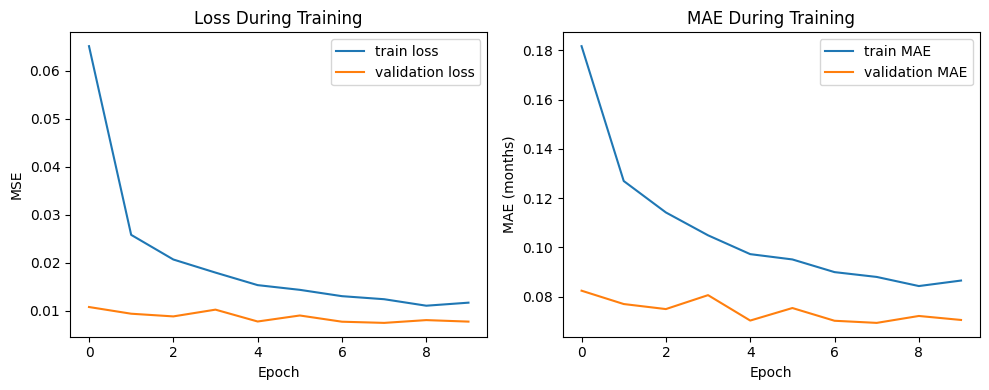

In [9]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.title("Loss During Training")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="train MAE")
plt.plot(history.history["val_mae"], label="validation MAE")
plt.title("MAE During Training")
plt.xlabel("Epoch")
plt.ylabel("MAE (months)")
plt.legend()

plt.tight_layout()
plt.show()

### A6. Evaluation & Results

All numbers in this section are computed on the held-out test set by actually running the model. For a regression problem the equivalent of a confusion matrix is a per-group error breakdown and a residual plot, so I report MAE overall, MAE by sex, and MAE by age band, and I plot the residuals.

I also show one prediction the model got close and one it clearly missed, with the true label printed next to the prediction. I expect the largest errors at the adolescent end, where growth plates have fused and images look more similar between ages.

In [10]:
if "boneage" not in test_df.columns:
    train_df, temp_df = train_test_split(df_raw_train, test_size=0.30, random_state=RANDOM_SEED)
    val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=RANDOM_SEED)
    available = set(os.listdir(DATA_ROOT))
    test_df = test_df[test_df["filename_id"].isin(available)].copy()
    print("Rebuilt labeled test set:", len(test_df), "images")


26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 532ms/step
Overall Test MAE: 16.54 months
MAE for Female: 16.95 months
MAE for Male: 16.18 months
MAE for under 6 years: 19.75 months
MAE for 6 to 12 years: 15.03 months
MAE for over 12 years: 17.72 months


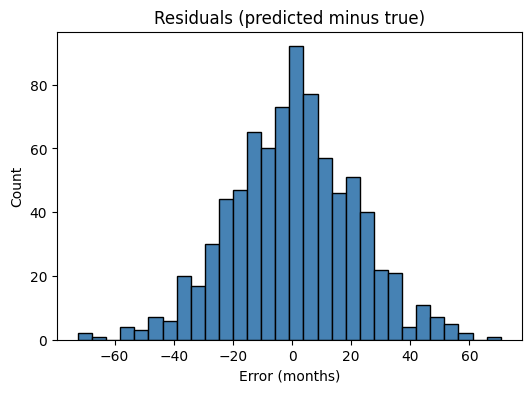

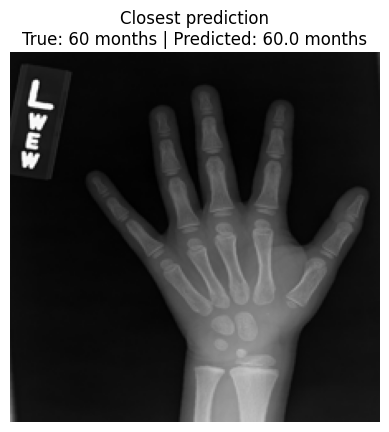

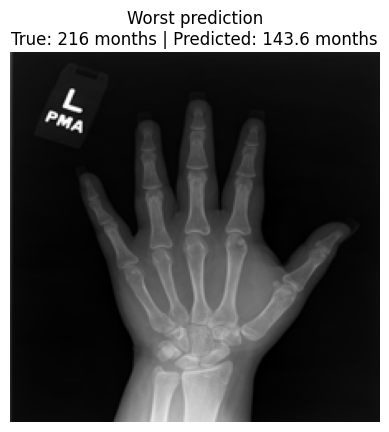

In [11]:
preds_scaled = model.predict(mu.make_dataset(test_df, DATA_ROOT, IMG_SIZE, shuffle=False))
preds = mu.scaled_to_months(preds_scaled.ravel())
truth = test_df["boneage"].to_numpy()
abs_err = np.abs(preds - truth)
print("Overall Test MAE:", round(float(abs_err.mean()), 2), "months")

for sex_value, sex_name in [(0.0, "Female"), (1.0, "Male")]:
    mask = test_df["male"] == sex_value
    if mask.sum() > 0:
        print(f"MAE for {sex_name}:", round(float(abs_err[mask.to_numpy()].mean()), 2), "months")

bins = [0, 72, 144, 1000]
labels = ["under 6 years", "6 to 12 years", "over 12 years"]
groups = pd.cut(test_df["boneage"], bins=bins, labels=labels)
for label in labels:
    mask = (groups == label).to_numpy()
    if mask.sum() > 0:
        print(f"MAE for {label}:", round(float(abs_err[mask].mean()), 2), "months")

plt.figure(figsize=(6, 4))
plt.hist(preds - truth, bins=30, color="steelblue", edgecolor="black")
plt.title("Residuals (predicted minus true)")
plt.xlabel("Error (months)")
plt.ylabel("Count")
plt.show()

best_idx = int(np.argmin(abs_err))
worst_idx = int(np.argmax(abs_err))

for idx, note in [(best_idx, "Closest prediction"), (worst_idx, "Worst prediction")]:
    row = test_df.iloc[idx]
    img = mu.load_and_preprocess_image(os.path.join(DATA_ROOT, row["filename_id"]), IMG_SIZE)
    disp = (img + 1.0) * 127.5
    plt.imshow(disp.astype("uint8"))
    plt.title(f"{note}\nTrue: {truth[idx]:.0f} months | Predicted: {preds[idx]:.1f} months")
    plt.axis("off")
    plt.show()


### A7. Model Export

I save the trained model to `bone_age_model.h5` with TensorFlow `2.21.0`.

The exact preprocessing any new image must go through before prediction, in the notebook and in the Streamlit app:
1. Resize to 224x224 pixels.
2. Convert to RGB (3 channels).
3. Cast to float32.
4. Scale with MobileNetV2's `preprocess_input` (pixels end up in [-1, 1]).
5. Add a batch dimension to make the shape (1, 224, 224, 3).

In [12]:
model.save("bone_age_model.h5")
config_path = mu.save_preprocessing_config(".")
print("Model export complete.")
print("File name: bone_age_model.h5")
print("Config saved to:", config_path)

Model export complete.
File name: bone_age_model.h5
Config saved to: ./preprocessing_config.json


### A8. Limitations, Ethics & Next Steps

My model was trained on images from a few hospitals, so it may not work well on other scanners, other populations, or age groups not in the training data.

A wrong prediction has real consequences. Overestimating bone age could lead to unnecessary tests or early treatment for suspected early puberty. Underestimating it could delay growth hormone treatment before growth plates close. This is why a tool like this should only assist a radiologist, never replace one.

Before real clinical use, the model would need testing on diverse multi-centre data, checks to reject images that look unlike training data, and regulatory approval such as FDA clearance or a local equivalent.

## Part B: Streamlit Diagnostic Portal

My Streamlit app in **app.py** loads **bone_age_model.h5** and applies the exact preprocessing from A7. It shows the predicted bone age in months and years, with a clear note that this is a coursework prototype and not a medical device. If an image does not look like a hand X-ray, the app says so instead of forcing a confident answer. The app shares its code with this notebook through `model_utils`, so the pipeline cannot drift apart.

In [ ]:
!streamlit run app.py

2026-09-14 18:45:17.198 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://192.168.100.163:8501

I0000 00:00:1789400718.300914  278232 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789400718.727974  278232 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789400720.639208  278232 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1789400722.842537  278232 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2026-09-14 18:46:21.305 Please replace `use_container_width` with `width`.

`use_container_width` will be removed af